## Deep Learning Model (Option C)

Define, train, and evaluate the deep learning classifier. Record training setup and report final metrics.


In [21]:
from pathlib import Path
import sys

# Add project root so src imports work when running from notebooks/.
sys.path.append(str(Path().resolve().parent))

from src.config import (
    PART1_KAGGLE_DIR,
    PART1_TRAIN_DIR,
    PART1_TEST_DIR,
)

# Validate Part 1 layout only (Part 2 is not needed for Option C)
assert PART1_TRAIN_DIR.exists(), f"Training data missing: {PART1_TRAIN_DIR}"
assert PART1_TEST_DIR.exists(), f"Test data missing: {PART1_TEST_DIR}"

print("Data paths validated:")
print(f"- Part 1 root : {PART1_KAGGLE_DIR}")
print(f"- Train       : {PART1_TRAIN_DIR}")
print(f"- Test        : {PART1_TEST_DIR}")

Data paths validated:
- Part 1 root : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle
- Train       : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/train/train
- Test        : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/test/test


### Imports & Device Setup

In [22]:
import importlib
import gc
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from src.config import (
    IMG_SIZE_CNN,
    CLASS_NAMES,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
)
import src.utils
importlib.reload(src.utils)
from src.utils import (
    load_labeled_images_memmap,
    get_pytorch_dataloaders,
    load_test_images_memmap,
    generate_submission_csv,
)
from src.evaluation import compute_metrics, compute_confusion_matrix
from src.visualization import (
    plot_confusion_matrix,
    plot_training_history,
    plot_sample_predictions,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = device.type == "cuda"
PIN_MEMORY = USE_CUDA

_nc = os.cpu_count() or 4
# Prefetch keeps the GPU fed; cap workers so memmap + host RAM stay stable.
DATALOADER_WORKERS = min(4, max(0, _nc - 1)) if USE_CUDA else 0
PREFETCH_FACTOR = 4 if DATALOADER_WORKERS > 0 else None

if USE_CUDA:
    print(f"Using device: {device}")
    print(f"CUDA (PyTorch build): {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
else:
    print(f"Using device: {device}")
    print("CUDA not available — CPU fallback.")

Using device: cuda
CUDA (PyTorch build): 13.0
GPU: NVIDIA GeForce RTX 5070 Ti


### Load Full Dataset

Load all labeled images at 224×224. One **stratified** split (**16 000** train / **4 000** val) replaces 5-fold CV. Progressive sizes (500 → … → 16 000) use the training pool for the scaling curve; the **holdout val** set gets predictions from the model trained on 16 000 for a quick accuracy check (not full-dataset OOF).

Saved weights and test-time inference use the **best validation checkpoint** from the progressive run trained on **16 000** images (same 16k/4k split).

> **Note:** Labeled images use an on-disk memmap; DataLoaders use `lazy_from_numpy=True` and row indices so batches read from disk **without** materializing `X[train_idx]` (that indexing copies the split into RAM and can exhaust memory).



In [ ]:
# Load the FULL dataset (no cap)
X, y = load_labeled_images_memmap(img_size=IMG_SIZE_CNN, grayscale=False, max_samples=None, rebuild=False)
print(f"Full dataset: {X.shape}, labels: {y.shape}")
print(f"  Class 0 (cat): {(y == 0).sum()},  Class; 1 (dog): {(y == 1).sum()}")

# Stratified holdout: 16k train / 4k val; progressive sizes use the 16k pool only
VAL_HOLDOUT = 4000
SAMPLE_SIZES_CV = [1000, 2000, 4000, 16000]
BATCH_SIZE = 48
print(f"\nHoldout: {len(y) - VAL_HOLDOUT} train / {VAL_HOLDOUT} val; progressive sizes: {SAMPLE_SIZES_CV}")
print(f"Batch size: {BATCH_SIZE} (raise if you have VRAM headroom, lower on OOM)")


Full dataset: (20000, 224, 224, 3), labels: (20000,)
  Class 0 (cat): 10021,  Class 1 (dog): 9979

Holdout: 16000 train / 4000 val; progressive sizes: [1000, 2000, 4000, 16000]
Batch size: 48 (raise if you have VRAM headroom, lower on OOM)


### Helper Functions

Define the model factory and training/evaluation loops used in the progressive training loop below.

In [25]:
import contextlib
from tqdm import tqdm
from torchvision.transforms import v2 as T

# Batched GPU augmentation (v2) — one forward through the aug stack per batch
gpu_augment = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomResizedCrop(IMG_SIZE_CNN, scale=(0.8, 1.0)),
    T.RandomErasing(p=0.1),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

USE_TORCH_COMPILE = USE_CUDA


def maybe_compile(m):
    if not USE_TORCH_COMPILE:
        return m
    try:
        return torch.compile(m, mode="default")
    except Exception as exc:
        print("torch.compile skipped:", exc)
        return m


def build_model(device):
    # DINOv2 ViT-B/14 (torch.hub); use dinov2_vits14 if VRAM is tight
    model = torch.hub.load(
        "facebookresearch/dinov2",
        "dinov2_vitb14",
        trust_repo=True,
    )
    for param in model.parameters():
        param.requires_grad = False
    embed_dim = model.embed_dim
    model.head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(embed_dim, 2),
    )
    model = model.to(device)
    model = maybe_compile(model)
    return model


def train_one_epoch(model, loader, criterion, optimizer, device, augment=None, scaler=None, use_amp=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    nb = PIN_MEMORY and device.type == "cuda"
    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images = images.to(device, non_blocking=nb)
        labels = labels.to(device, non_blocking=nb)
        if augment is not None:
            images = augment(images)
        optimizer.zero_grad(set_to_none=True)
        with amp_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_amp=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    nb = PIN_MEMORY and device.type == "cuda"
    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )
    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=nb)
        labels = labels.to(device, non_blocking=nb)
        with amp_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


print("Helper functions defined.")

Helper functions defined.


### Progressive Training

For each dataset size in `SAMPLE_SIZES`, train a fresh **DINOv2 ViT-B/14** through two phases:

1. **Phase 1 — Head only** (12 epochs, lr=1e-3, cosine annealing)
2. **Phase 2 — Full fine-tuning** (20 epochs, lr=1e-5, cosine annealing)

Backbone: `torch.hub` DINOv2 (`dinov2_vitb14`); swap to `dinov2_vits14` in `build_model` if you hit OOM. Same augmentation (random flips,
rotation, colour jitter, random erasing), cosine-annealing LR, dropout in head.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

grad_scaler = torch.amp.GradScaler("cuda", enabled=USE_CUDA)

NUM_EPOCHS_HEAD = 8
NUM_EPOCHS_FULL = 12

train_idx, val_idx = train_test_split(
    np.arange(len(y), dtype=np.int64),
    test_size=VAL_HOLDOUT,
    stratify=y,
    random_state=42,
)

oof_pred = np.zeros(len(y), dtype=np.int64)
cv_progressive_results = []

loader_kw = dict(
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE_CNN,
    normalize_train=False,
    lazy_from_numpy=True,
    num_workers=DATALOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=DATALOADER_WORKERS > 0,
    prefetch_factor=PREFETCH_FACTOR,
)

def run_training_phases(model, train_loader, val_loader, criterion, grad_scaler, use_amp):
    history = {"train_loss": [], "train_acc": []}
    if val_loader is not None:
        history["val_loss"] = []
        history["val_acc"] = []
    best_val_acc = 0.0
    best_state = None

    head_params = [p for p in model.head.parameters() if p.requires_grad]
    optimizer = optim.Adam(head_params, lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_HEAD)

    print(f"  Phase 1: FC head only for {NUM_EPOCHS_HEAD} epochs")
    for epoch in range(1, NUM_EPOCHS_HEAD + 1):
        tl, ta = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            augment=gpu_augment, scaler=grad_scaler, use_amp=use_amp,
        )
        if val_loader is not None:
            vl, va = evaluate(model, val_loader, criterion, device, use_amp=use_amp)
            history["val_loss"].append(vl)
            history["val_acc"].append(va)
        else:
            vl, va = tl, ta
        scheduler.step()
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        line = f"    Epoch {epoch}/{NUM_EPOCHS_HEAD} — TrL:{tl:.4f} TrA:{ta:.4f}"
        if val_loader is not None:
            line += f" VL:{vl:.4f} VA:{va:.4f}"
        print(line)
        if val_loader is not None:
            if va > best_val_acc:
                best_val_acc = va
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    for param in model.parameters():
        param.requires_grad = True
    optimizer_ft = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=NUM_EPOCHS_FULL)

    print(f"  Phase 2: Full fine-tuning for {NUM_EPOCHS_FULL} epochs")
    for epoch in range(1, NUM_EPOCHS_FULL + 1):
        tl, ta = train_one_epoch(
            model, train_loader, criterion, optimizer_ft, device,
            augment=gpu_augment, scaler=grad_scaler, use_amp=use_amp,
        )
        if val_loader is not None:
            vl, va = evaluate(model, val_loader, criterion, device, use_amp=use_amp)
            history["val_loss"].append(vl)
            history["val_acc"].append(va)
        else:
            vl, va = tl, ta
        scheduler_ft.step()
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        line = f"    Epoch {epoch}/{NUM_EPOCHS_FULL} — TrL:{tl:.4f} TrA:{ta:.4f}"
        if val_loader is not None:
            line += f" VL:{vl:.4f} VA:{va:.4f}"
        print(line)
        if val_loader is not None:
            if va > best_val_acc:
                best_val_acc = va
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if val_loader is None:
        best_val_acc = float("nan")

    return best_state, best_val_acc, history

print(f"\n{'='*60}")
print(f"Train/val split  |  train={len(train_idx)}  val={len(val_idx)}")
print(f"{'='*60}")

# Index memmap by row id in the loader (avoids copying X[train_idx] into RAM).
y_train_fold = y[train_idx]
y_val_fold = y[val_idx]

best_state_oof = None

for n_samples in SAMPLE_SIZES_CV:
    print(f"\n--- Progressive size {n_samples} (max fold train={len(y_train_fold)}) ---")

    if n_samples < len(train_idx):
        pool = np.arange(len(train_idx), dtype=np.int64)
        sub_pool = resample(
            pool,
            n_samples=n_samples,
            stratify=y_train_fold,
            random_state=42,
        )
        idx_train = train_idx[sub_pool]
        y_sub = y[idx_train]
    else:
        idx_train = train_idx
        y_sub = y_train_fold

    train_loader, val_loader = get_pytorch_dataloaders(
        X, y_sub, X, y_val_fold,
        train_row_indices=idx_train,
        val_row_indices=val_idx,
        **loader_kw,
    )
    print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    model = build_model(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    best_state, best_val_acc, history = run_training_phases(
        model, train_loader, val_loader, criterion, grad_scaler, USE_CUDA,
    )
    best_state_oof = best_state

    cv_progressive_results.append({
        "n_train": n_samples,
        "best_val_acc": best_val_acc,
        "history": history,
    })
    print(f"  ✓ Best val accuracy: {best_val_acc:.4f}")

    del train_loader, val_loader, model
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

model_oof = build_model(device)
model_oof.load_state_dict(best_state_oof)
model_oof.eval()
_, val_loader_oof = get_pytorch_dataloaders(
    X, y_train_fold[:1], X, y_val_fold,
    train_row_indices=train_idx[:1],
    val_row_indices=val_idx,
    **loader_kw,
)
fold_preds = []
nb = PIN_MEMORY and device.type == "cuda"
amp_inf = torch.amp.autocast("cuda", enabled=USE_CUDA)
with torch.no_grad():
    for images, labels in tqdm(val_loader_oof, desc="Val infer", leave=False):
        images = images.to(device, non_blocking=nb)
        with amp_inf:
            outputs = model_oof(images)
        fold_preds.append(outputs.argmax(dim=1).cpu().numpy())
oof_pred[val_idx] = np.concatenate(fold_preds)
del model_oof, val_loader_oof
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

final_history = cv_progressive_results[-1]["history"]

model = build_model(device)
model.load_state_dict(best_state_oof)
model = model.to(device)

_, val_loader = get_pytorch_dataloaders(
    X, y_train_fold[:1], X, y_val_fold,
    train_row_indices=train_idx[:1],
    val_row_indices=val_idx,
    **loader_kw,
)

progressive_results = []
for n in SAMPLE_SIZES_CV:
    accs = [r["best_val_acc"] for r in cv_progressive_results if r["n_train"] == n]
    progressive_results.append({
        "n_train": n,
        "best_val_acc": float(np.mean(accs)),
        "std_val_acc": float(np.std(accs)),
        "history": None,
    })

print("\n--- Progressive summary (single split) ---")
for r in progressive_results:
    print(f"  {r['n_train']:>6d} images → val acc = {r['best_val_acc']:.4f} ± {r['std_val_acc']:.4f}")

print("\n--- Holdout val accuracy (4000 images, trained on up to 16k) ---")
print(f"  {(oof_pred[val_idx] == y[val_idx]).mean():.4f}")

y_pred_eval = oof_pred
y_true_eval = np.asarray(y)



Train/val split  |  train=16000  val=4000

--- Progressive size 1000 (max fold train=16000) ---
  Train batches: 21, Val batches: 84
Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /home/cotte/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 106MB/s]  


  Phase 1: FC head only for 12 epochs


    Epoch 1/12 — TrL:0.4062 TrA:0.8560 VL:0.2125 VA:0.9835


    Epoch 2/12 — TrL:0.1995 TrA:0.9760 VL:0.1695 VA:0.9920


...

    Epoch 17/20 — TrL:0.1465 TrA:0.9925 VL:0.1379 VA:0.9962


    Epoch 18/20 — TrL:0.1478 TrA:0.9921 VL:0.1379 VA:0.9962


    Epoch 19/20 — TrL:0.1473 TrA:0.9928 VL:0.1379 VA:0.9962


    Epoch 20/20 — TrL:0.1491 TrA:0.9912 VL:0.1379 VA:0.9962
  ✓ Best val accuracy: 0.9968



--- Progressive summary (single split) ---
    1000 images → val acc = 0.9950 ± 0.0000
    2000 images → val acc = 0.9962 ± 0.0000
    4000 images → val acc = 0.9965 ± 0.0000
   16000 images → val acc = 0.9968 ± 0.0000

--- Holdout val accuracy (4000 images, trained on up to 16k) ---
  0.9968


### Training Curves (Final Run) & Data Scaling Curve

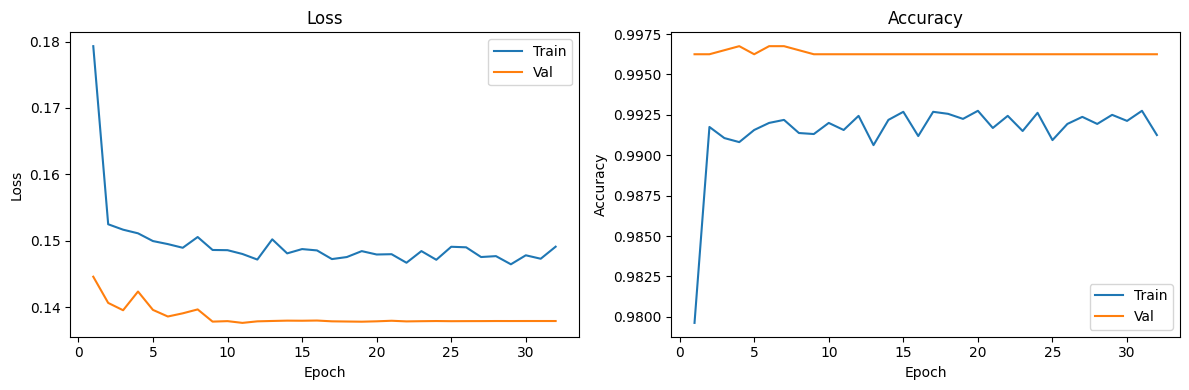

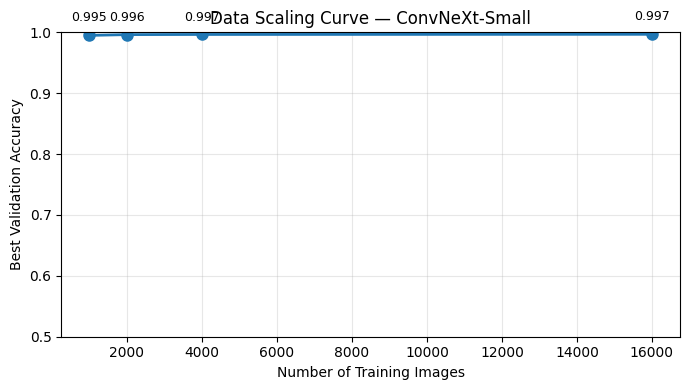

Saved data_scaling_curve_optionC.png


In [27]:
import matplotlib.pyplot as plt

# 1) Training history from the max-size progressive run (16k train / 4k val)
plot_training_history(final_history, save_path=FIGURES_DIR / "training_history_optionC.png")

# 2) Data scaling curve: val accuracy vs training set size
sizes = [r["n_train"] for r in progressive_results]
accs  = [r["best_val_acc"] for r in progressive_results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, accs, "o-", linewidth=2, markersize=8)
ax.set_xlabel("Number of Training Images")
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Data Scaling Curve — DINOv2 ViT-B/14")
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)
for s, a in zip(sizes, accs):
    ax.annotate(f"{a:.3f}", (s, a), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "data_scaling_curve_optionC.png", dpi=150)
plt.show()
print("Saved data_scaling_curve_optionC.png")

### Evaluation on Internal Test Split

Run inference on the held-out validation set (Internal Test Split) and compute classification metrics + confusion matrix.

In [28]:
# Collect predictions on the validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    nb = PIN_MEMORY and device.type == "cuda"
    for images, labels in tqdm(val_loader, desc="Inference"):
        images = images.to(device, non_blocking=nb)
        with torch.amp.autocast("cuda", enabled=USE_CUDA):
            outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Compute metrics
metrics_c = compute_metrics(y_true, y_pred)
print("Option C (DINOv2 ViT-B/14) Metrics:")
for k, v in metrics_c.items():
    print(f"  {k:>10s}: {v:.4f}")

# Confusion matrix
cm = compute_confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Inference: 100%|██████████| 84/84 [00:02<00:00, 37.77it/s]

Option C (CNN — ConvNeXt-Small) Metrics:
    accuracy: 0.9968
   precision: 0.9975
      recall: 0.9960
          f1: 0.9967

Confusion Matrix:
[[1999    5]
 [   8 1988]]


### Wrong validation predictions (16k model)

Held-out validation errors for the **best checkpoint from the 16 000-image progressive run**, sorted by **descending confidence in the predicted (wrong) class** (most confident mistakes first). Displays up to 36 images.


Predicted-class confidence on validation (all 4000 samples):
  <0.5:               0  (  0.0%)
  Low 0.50–0.55:      5  (  0.1%)
  0.55–0.70:         17  (  0.4%)
  0.70–0.80:         21  (  0.5%)
  0.80–1.00:       3957  ( 98.9%)


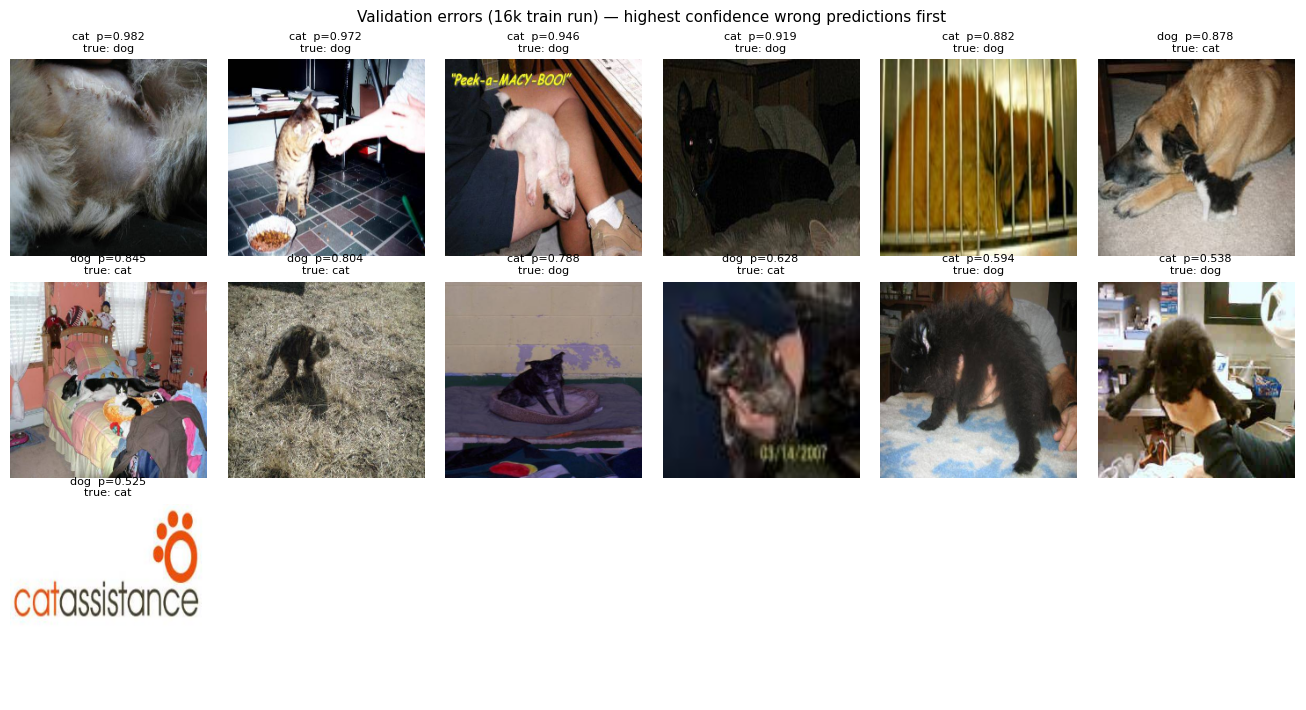

Saved: /home/cotte/github/school/ecse415-final-project/outputs/figures/optionC_val_errors_by_confidence.png
Wrong on val: 13 / 4000


In [33]:
# Validation errors (16k-trained model): show wrong predictions sorted by confidence in the predicted class
from operator import itemgetter

model.eval()
batch_pred_prob = []
batch_preds = []
batch_labels = []

with torch.no_grad():
    nb = PIN_MEMORY and device.type == "cuda"
    amp_inf = torch.amp.autocast("cuda", enabled=USE_CUDA)
    for images, labels in tqdm(val_loader, desc="Val probs (errors)", leave=False):
        images = images.to(device, non_blocking=nb)
        with amp_inf:
            outputs = model(images)
        probs = torch.softmax(outputs.float(), dim=1)
        pred = outputs.argmax(dim=1)
        row = torch.arange(probs.size(0), device=probs.device)
        pred_prob = probs[row, pred].cpu().numpy()
        batch_pred_prob.append(pred_prob)
        batch_preds.append(pred.cpu().numpy())
        batch_labels.append(labels.numpy())

pred_class_prob = np.concatenate(batch_pred_prob)
y_pred_p = np.concatenate(batch_preds)
y_true_p = np.concatenate(batch_labels)

n_val = len(pred_class_prob)
n_below = 0
n_b0 = 0
n_b1 = 0
n_b2 = 0
n_b3 = 0
for v in pred_class_prob:
    if v < 0.5:
        n_below += 1
    elif v < 0.55:
        n_b0 += 1
    elif v < 0.7:
        n_b1 += 1
    elif v < 0.8:
        n_b2 += 1
    else:
        n_b3 += 1

print("\nPredicted-class confidence on validation (all %d samples):" % n_val)
print("  <0.5:           %5d  (%5.1f%%)" % (n_below, 100.0 * n_below / n_val))
print("  Low 0.50–0.55:  %5d  (%5.1f%%)" % (n_b0, 100.0 * n_b0 / n_val))
print("  0.55–0.70:      %5d  (%5.1f%%)" % (n_b1, 100.0 * n_b1 / n_val))
print("  0.70–0.80:      %5d  (%5.1f%%)" % (n_b2, 100.0 * n_b2 / n_val))
print("  0.80–1.00:      %5d  (%5.1f%%)" % (n_b3, 100.0 * n_b3 / n_val))

wrong_i = []
for i in range(len(y_true_p)):
    if y_pred_p[i] != y_true_p[i]:
        wrong_i.append(i)

wrong_rows = []
for i in wrong_i:
    wrong_rows.append((i, float(pred_class_prob[i])))

wrong_sorted = sorted(wrong_rows, key=itemgetter(1), reverse=True)

if len(wrong_sorted) == 0:
    print("No wrong predictions on the validation split.")
else:
    n_show = min(len(wrong_sorted), 36)
    ncols = 6
    nrows = int(np.ceil(n_show / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.4))
    axes_flat = np.atleast_1d(axes).ravel()

    for j in range(len(axes_flat)):
        ax = axes_flat[j]
        if j < n_show:
            vi, conf = wrong_sorted[j]
            row = int(val_idx[vi])
            img = X[row]
            ax.imshow(img)
            true_name = CLASS_NAMES[int(y_true_p[vi])]
            pred_name = CLASS_NAMES[int(y_pred_p[vi])]
            ax.set_title(f"{pred_name}  p={conf:.3f}\ntrue: {true_name}", fontsize=8)
        ax.axis("off")

    fig.suptitle("Validation errors (16k train run) — highest confidence wrong predictions first", fontsize=11)
    fig.tight_layout()
    out_err = FIGURES_DIR / "optionC_val_errors_by_confidence.png"
    fig.savefig(out_err, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out_err)
    print(f"Wrong on val: {len(wrong_i)} / {len(y_true_p)}")

### Confusion Matrix & Sample Predictions

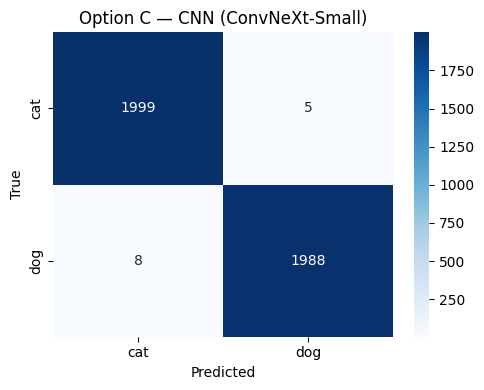

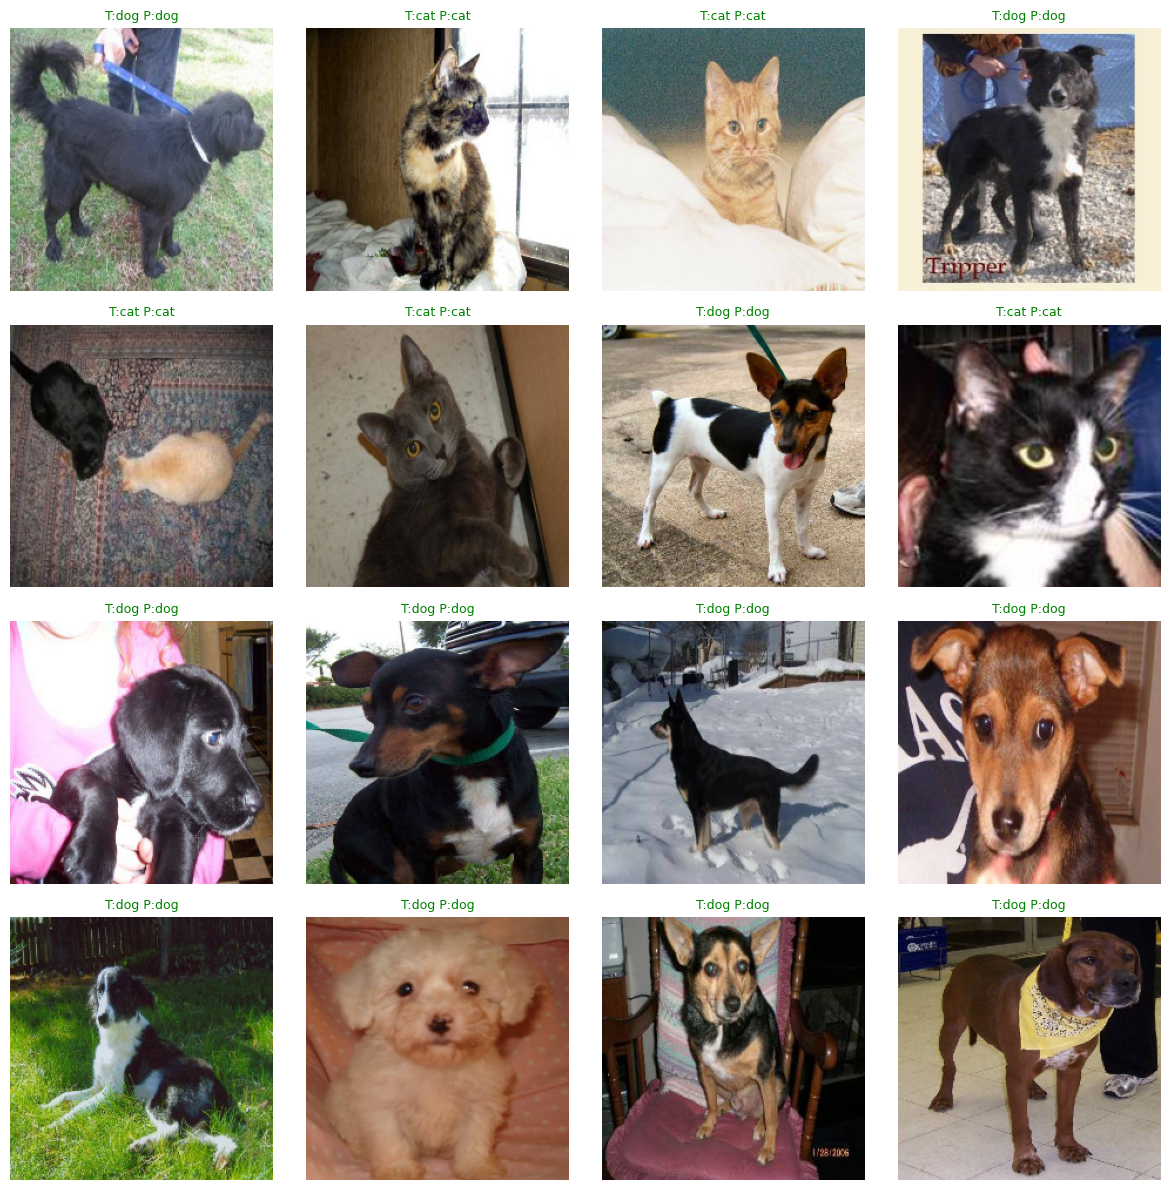

In [29]:
plot_confusion_matrix(
    cm,
    class_names=CLASS_NAMES,
    title="Option C — DINOv2 ViT-B/14",
    save_path=FIGURES_DIR / "confusion_matrix_optionC.png",
)

plot_sample_predictions(
    X[val_idx[:16]],
    y_true[:16],
    y_pred[:16],
    class_names=CLASS_NAMES,
    n=16,
    save_path=FIGURES_DIR / "sample_predictions_optionC.png",
)

### Save Model & Metrics

In [30]:
import json

# Save model weights
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "option_c_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Save metrics as JSON for notebook 04 to load
metrics_path = MODELS_DIR / "metrics_optionC.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_c, f, indent=2)
print(f"Metrics saved to {metrics_path}")
print(metrics_c)

Model saved to /home/cotte/github/school/ecse415-final-project/outputs/models/option_c_cnn.pth
Metrics saved to /home/cotte/github/school/ecse415-final-project/outputs/models/metrics_optionC.json
{'accuracy': 0.99675, 'precision': 0.997491219267436, 'recall': 0.9959919839679359, 'f1': 0.9967410378540987}


### Kaggle Submission (with TTA)

Generate predictions on the unlabeled Kaggle Public Test Set using **Test-Time Augmentation**: average softmax probabilities from the original image and its horizontal flip, then take argmax. The label column contains integer class labels: **0 = Cat, 1 = Dog**.

In [31]:
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Load unlabeled test images
X_test, test_ids = load_test_images_memmap(img_size=IMG_SIZE_CNN, grayscale=False)
print(f"Test images: {X_test.shape}, IDs: {len(test_ids)}")

# Prepare test tensors (NCHW float)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
X_test_base = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()

# ── Test-Time Augmentation (TTA) ─────────────────────────────────────────
# Average softmax probabilities over the original image + a horizontally-
# flipped copy to improve prediction robustness.
tta_transforms = [
    lambda t: t,                       # identity (original)
    lambda t: torch.flip(t, dims=[3]), # horizontal flip
]

model.eval()
avg_probs = None

for tta_idx, tta_fn in enumerate(tta_transforms):
    X_aug = tta_fn(X_test_base.clone())
    X_aug = torch.stack([normalize(img) for img in X_aug])
    test_ds = TensorDataset(X_aug)
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=DATALOADER_WORKERS > 0,
        prefetch_factor=2 if DATALOADER_WORKERS > 0 else None,
    )

    all_probs = []
    nb = PIN_MEMORY and device.type == "cuda"
    with torch.no_grad():
        for (images,) in tqdm(test_loader, desc=f"TTA pass {tta_idx+1}/{len(tta_transforms)}"):
            images = images.to(device, non_blocking=nb)
            with torch.amp.autocast("cuda", enabled=USE_CUDA):
                outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu()
            all_probs.append(probs)

    probs_tensor = torch.cat(all_probs, dim=0)  # (N, 2)
    if avg_probs is None:
        avg_probs = probs_tensor
    else:
        avg_probs = avg_probs + probs_tensor

avg_probs = avg_probs / len(tta_transforms)
predictions = avg_probs.argmax(dim=1).numpy()

# Write CSV with integer labels (Kaggle expects 0/1, not probabilities)
submission_path = generate_submission_csv(
    test_ids, predictions, OUTPUTS_DIR / "submissions" / "submission_optionC.csv"
)
print(f"Submission saved to {submission_path}  ({len(test_ids)} rows)")
print(f"  Dogs: {(predictions == 1).sum()}, Cats: {(predictions == 0).sum()}")

Test images: (5000, 224, 224, 3), IDs: 5000


TTA pass 2/2: 100%|██████████| 105/105 [00:02<00:00, 39.07it/s]


Submission saved to /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC.csv  (5000 rows)
  Dogs: 2526, Cats: 2474
